# Australian Coral Reef

**Exploratory Data Analysis** using *Matplotlib* and *Seaborn* for **visualization**

Description of Data in Dataset

| Column | Description |
|:---|:---|
| `Station ID` | ID of the station where the sample was collected. |
| `MMP_SITE_NAME` | Name of the Marine Monitoring Program (MMP) site where the sample was collected. |
| `LONGITUDE` | Longitude of the sampling site. |
| `LATITUDE` | Latitude of the sampling site. |
| `LOGGER_SERIAL` | Serial number of the data logger that recorded the readings. |
| `SAMPLE_DAY` | Date the sample was collected. |
| `CHL_QA_AVG` | Daily average chlorophyll concentration in the water, measured in ug/L (micrograms per litre). |
| `NTU_QA_AVG` | Daily average turbidity, measured in NTU (Nephelometric Turbidity Units). Turbidity shows how cloudy the water is because of suspended particles. |

## Importing Required Libraries and Importing Dataset

In [345]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import MultipleLocator

df=pd.read_csv("data/combined_marine_dataset_3sites.csv") #dataset is imported into df - the pandas DataFrame

## Exploring Dataset

In [348]:
df.head() # first few rows of df

,STATION_ID,MMP_SITE_NAME,LONGITUDE,LATITUDE,LOGGER_SERIAL,SAMPLE_DAY,CHL_QA_AVG,NTU_QA_AVG
0,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-22,1.910,3.901
1,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-23,1.935,3.958
2,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-24,1.867,2.408
3,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-25,2.166,1.352
4,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-26,1.911,1.058


### Exploring Numerical Data

In [351]:
df.describe() #summary of numerical data

,LONGITUDE,LATITUDE,LOGGER_SERIAL,CHL_QA_AVG,NTU_QA_AVG
count,7786.000000,7786.000000,7786.000000,7786.000000,7744.000000
mean,147.559106,-19.089235,1620.652453,0.717835,4.148771
std,1.128056,1.404675,1857.961498,0.396201,6.656222
min,145.996300,-20.377900,351.000000,0.035000,0.274000
25%,145.996300,-20.377900,822.000000,0.436000,0.998750
50%,147.582200,-19.587500,842.000000,0.702000,2.020000
75%,148.888400,-16.923200,1329.000000,0.941000,4.747250
max,148.888400,-16.923200,7380.000000,7.965000,117.268000


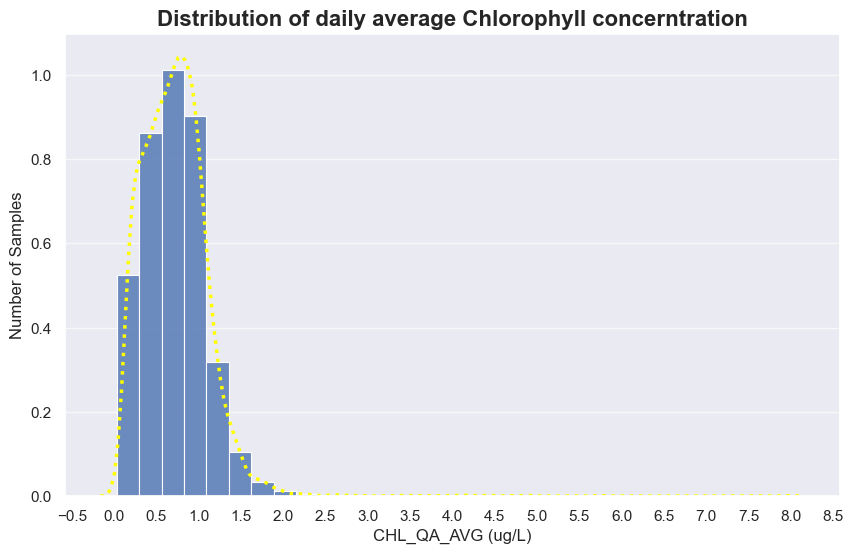

In [383]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="CHL_QA_AVG",
    bins=30,
    stat="density",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.8
)

sns.kdeplot(
    data=df,
    x="CHL_QA_AVG",
    color="yellow",
    linestyle=":",
    linewidth=2.5
)

plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))

plt.title("Distribution of daily average Chlorophyll concerntration", fontsize=16, fontweight="bold")
plt.xlabel("CHL_QA_AVG (ug/L)", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.grid(axis="x", alpha=0)
plt.grid(axis="y", alpha=0.7)
plt.show()

<span style="color:red"><strong>Heavily Right Skewed, or Positively Skewed; average value across all samples is 0.717 µg/L. Average values across stations are shown below:</strong></span>

In [195]:
print(df.groupby("STATION_ID")["CHL_QA_AVG"].mean())

STATION_ID
BUR13      0.971765
Fitzroy    0.383340
Pine       0.706653
Name: CHL_QA_AVG, dtype: float64


<span style="color:red"><strong>Chlorophyll Concerntration is considerably lower in Fitzroy!</strong></span>

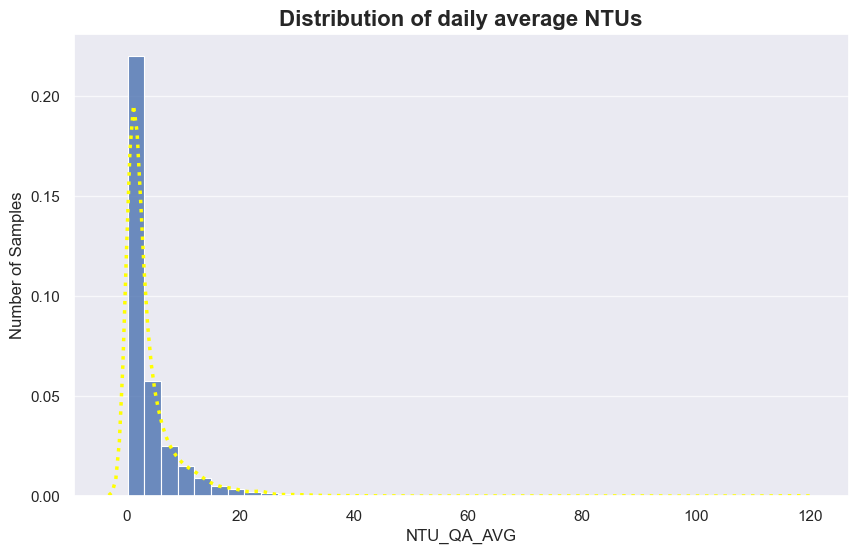

In [381]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="NTU_QA_AVG",
    bins=40,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.8,
    stat="density"
)

sns.kdeplot(
    data=df,
    x="NTU_QA_AVG",
    color="yellow",
    linestyle=":",
    linewidth=2.5
)

plt.title("Distribution of daily average NTUs", fontsize=16, fontweight="bold")
plt.xlabel("NTU_QA_AVG", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.grid(axis="x", alpha=0)
plt.grid(axis="y", alpha=0.7)
plt.show()

<span style="color:red"><strong>Also heavily Right Skewed, or Positively Skewed; average value across all samples is 4.15NTUs. Average values across stations are shown below:</strong></span>

In [217]:
print(df.groupby("STATION_ID")["NTU_QA_AVG"].mean())

STATION_ID
BUR13      7.736508
Fitzroy    1.195712
Pine       2.510765
Name: NTU_QA_AVG, dtype: float64


<span style="color:red"><strong>Samples collected from Burkdein Rivermouth are considerbly more Polluted/Cloudier than samples from the other two stations. The samples collected from Fitzroy are the clearest.</strong></span>

### Exploring Categorical Data

In [27]:
df["MMP_SITE_NAME"].value_counts()

MMP_SITE_NAME
Burdekin River mouth mooring    3026
Pine                            2548
Fitzroy West                    2212
Name: count, dtype: int64

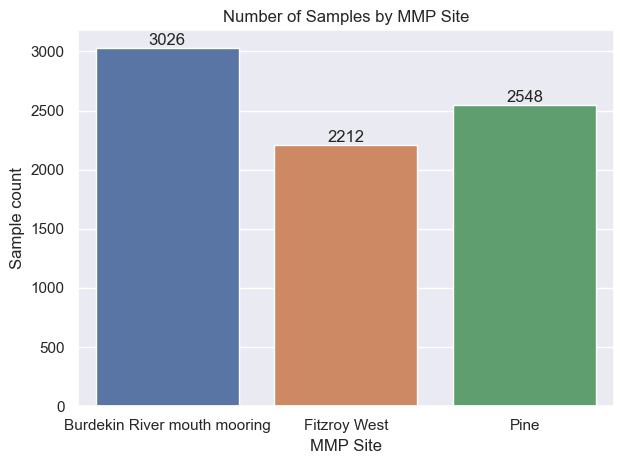

In [116]:
#visualizing the above result using a countplot (basically a histogram)
sns.set_theme(style="darkgrid", palette="deep")

ax = sns.countplot(
    data=df,
    x="MMP_SITE_NAME",
    hue="MMP_SITE_NAME",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Samples by MMP Site")
plt.xlabel("MMP Site")
plt.ylabel("Sample count")
plt.tight_layout()
plt.show()

<span style="color:red"><strong>Most samples (3026) have been taken from Burdekin River Mouth Mooring, while the least samples (2212) have been taken from Fitzroy West.</strong></span>

In [141]:
counts = df.groupby(["STATION_ID", "LOGGER_SERIAL"]).size().reset_index(name="count")
print(counts)

   STATION_ID  LOGGER_SERIAL  count
0       BUR13            351    167
1       BUR13            818    163
2       BUR13            819     77
3       BUR13            822    156
4       BUR13            824    166
5       BUR13            826    118
6       BUR13            828    177
7       BUR13            837    115
8       BUR13            838    133
9       BUR13            844     86
10      BUR13            846    182
11      BUR13           1043    274
12      BUR13           1091    115
13      BUR13           1329     61
14      BUR13           1464    192
15      BUR13           1729    118
16      BUR13           1958    227
17      BUR13           2332    224
18      BUR13           6668    128
19      BUR13           6703    147
20    Fitzroy            351    118
21    Fitzroy            816    106
22    Fitzroy            817    259
23    Fitzroy            819     45
24    Fitzroy            826    190
25    Fitzroy            827    147
26    Fitzroy            828

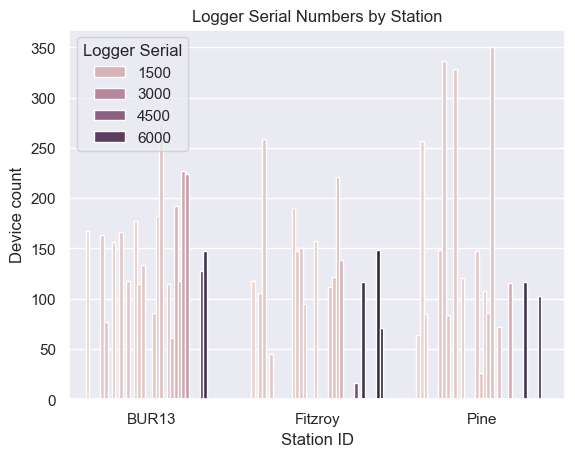

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

counts = df.groupby(["STATION_ID", "LOGGER_SERIAL"]).size().reset_index(name="count")

sns.barplot(
    data=counts,
    x="STATION_ID",
    y="count",
    hue="LOGGER_SERIAL"
)

plt.title("Logger Serial Numbers by Station")
plt.xlabel("Station ID")
plt.ylabel("Device count")
plt.legend(title="Logger Serial")
plt.show()

<span style="color:red"><strong>Many different Data Loggers across the 3 Sites, refer to Value Counts above to get a clear, full picture, Visualization of a large categorical variables is difficult in this way. The heatmap below may be useful to check common Data Loggers across sites.</strong></span>

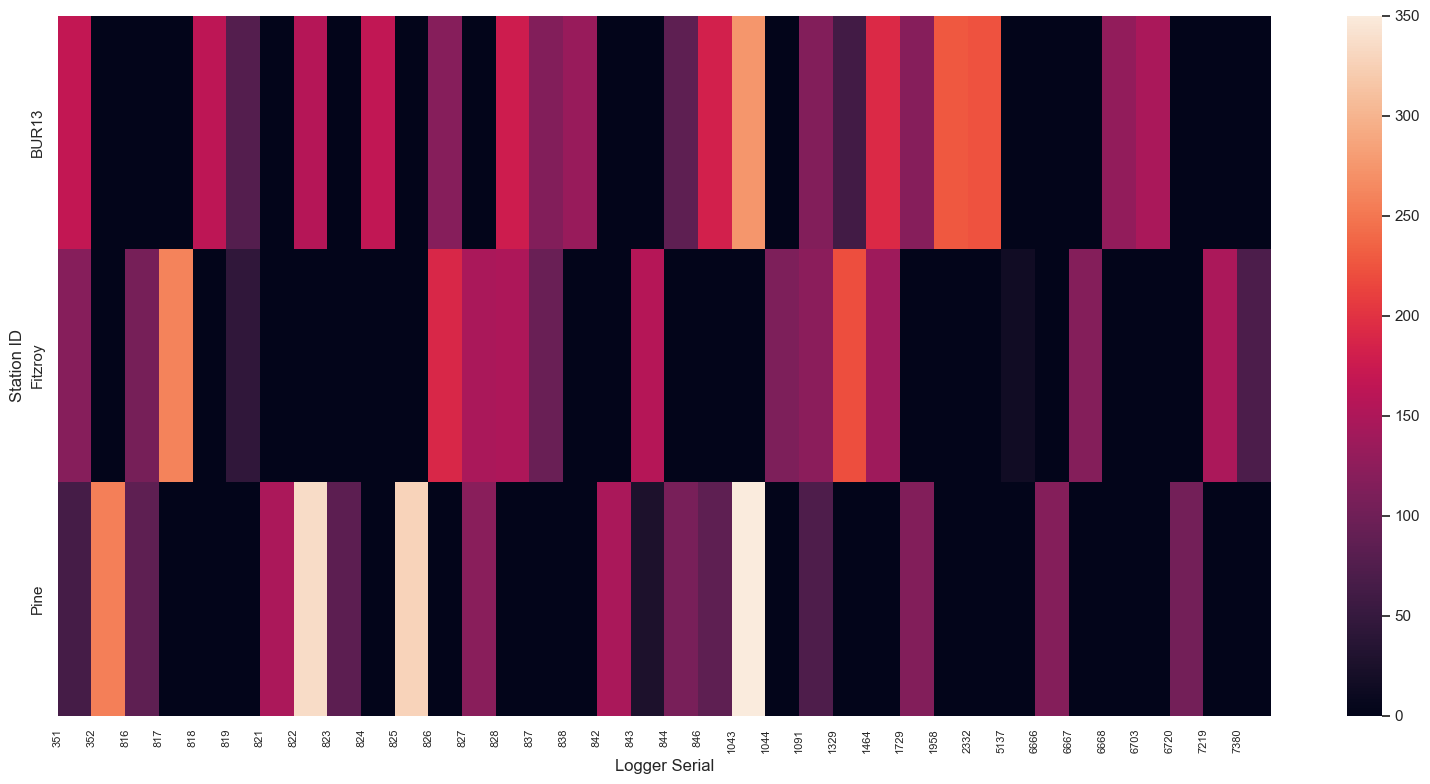

In [152]:
plt.figure(figsize=(16, 8))

table = pd.crosstab(df["STATION_ID"], df["LOGGER_SERIAL"])

sns.heatmap(table)

plt.xticks(
    ticks=range(len(table.columns)),
    labels=table.columns,
    rotation=90,
    fontsize=8
)

plt.xlabel("Logger Serial")
plt.ylabel("Station ID")
plt.tight_layout()
plt.show()

<span style="color:red"><strong>From this heatmap, you can see that Devices with serial nos: 351, 816, 819, 846, 1729 are among some of the Serials of devices that are available at two or more sites.</strong></span>

## Visualizations

### Median NTU & CHL measurements at sites

<span style="color:red"><strong>Understanding and monitoring turbidity and chlorophyll levels is crucial for maintaining healthy, thriving coral reefs. Turbidity indicates sediment pollution, which can quickly damage coral ecosystems. Similarly, chlorophyll helps track long-term nutrient pollution. Elevated chlorophyll levels often signal excess nutrients, which can be harmful to coral survival.</strong></span>

In [244]:
grouped_measurements = df.groupby("STATION_ID")[["NTU_QA_AVG","CHL_QA_AVG"]].median()
grouped_measurements

,NTU_QA_AVG,CHL_QA_AVG
STATION_ID,,
BUR13,5.1905,0.9670
Fitzroy,0.8840,0.3200
Pine,1.9075,0.7085


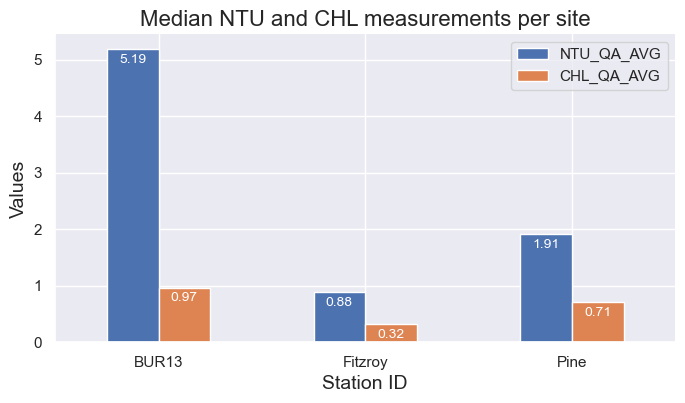

In [278]:
# group the measurements by STATION_ID and find the median values for NTU_QA_AVG and CHL_QA_AVG
grouped_measurements = df.groupby("STATION_ID")[["NTU_QA_AVG","CHL_QA_AVG"]].median()

# plot the column chart. set the figsize to (8,4)
ax_bar = grouped_measurements.plot(kind="bar", figsize=(8,4))

# customize the plot
plt.xlabel("Station ID", fontsize=14)
plt.ylabel("Values", fontsize=14)
plt.title("Median NTU and CHL measurements per site", fontsize=16)

# rotate the x-axis labels
plt.xticks(rotation=0)

# remove top & right spine
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# add data labels inside each bar
for container in ax_bar.containers:
    ax_bar.bar_label(
        container,
        fontsize=10,
        fmt="%.2f",
        label_type="edge",
        color="white",
        padding=-12,
    )

plt.show()

<span style="color:red"><strong>There is significantly more Sediment Pollution shown by the average NTU reading at Burdekin River Mouth mooring, this is the water quality event authorities should be focusing their efforts on immediately to maintain healthy corals.</strong></span>

### Correlation between NTU & CHL averages

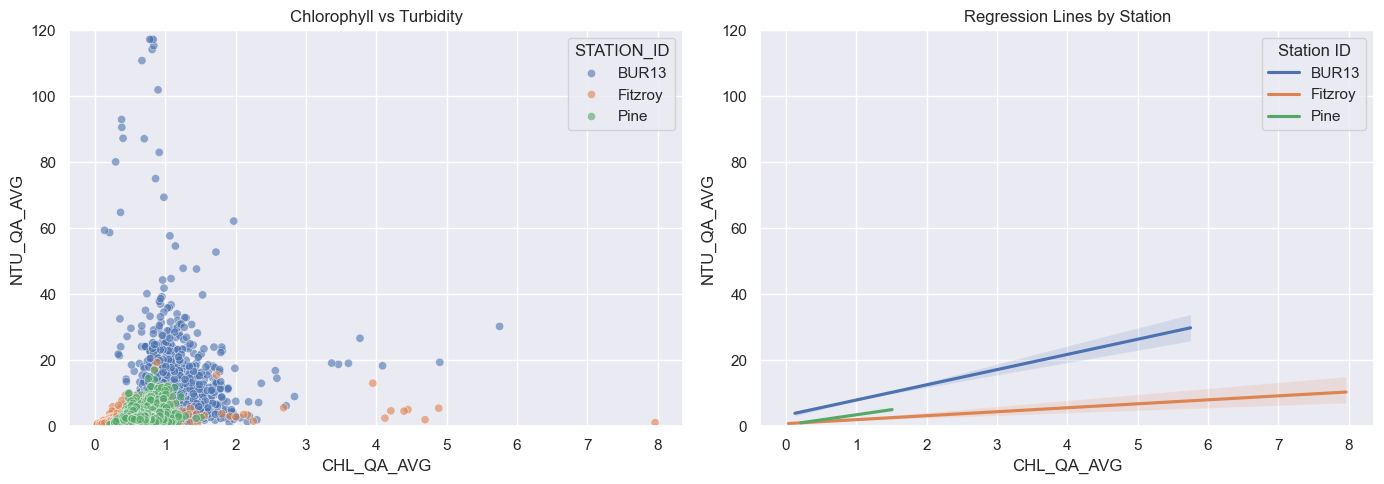

In [332]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Scatter plot
sns.scatterplot(
    data=df,
    x="CHL_QA_AVG",
    y="NTU_QA_AVG",
    hue="STATION_ID",
    alpha=0.6,
    ax=axes[0]
)

axes[0].set_title("Chlorophyll vs Turbidity")
axes[0].set_xlabel("CHL_QA_AVG")
axes[0].set_ylabel("NTU_QA_AVG")
axes[0].set_ylim(0, 120)


# 2) Regression lines
for station in df["STATION_ID"].unique():
    station_data = df[df["STATION_ID"] == station]

    sns.regplot(
        data=station_data,
        x="CHL_QA_AVG",
        y="NTU_QA_AVG",
        scatter=False,
        label=station,
        ax=axes[1]
    )

axes[1].set_title("Regression Lines by Station")
axes[1].set_xlabel("CHL_QA_AVG")
axes[1].set_ylabel("NTU_QA_AVG")
axes[1].set_ylim(0, 120)
axes[1].legend(title="Station ID")

plt.tight_layout()
plt.show()

In [300]:
df.groupby("STATION_ID")[["CHL_QA_AVG","NTU_QA_AVG"]].corr()

CHL_QA_AVG  NTU_QA_AVG
STATION_ID                                   
BUR13      CHL_QA_AVG    1.000000    0.177851
           NTU_QA_AVG    0.177851    1.000000
Fitzroy    CHL_QA_AVG    1.000000    0.374685
           NTU_QA_AVG    0.374685    1.000000
Pine       CHL_QA_AVG    1.000000    0.283980
           NTU_QA_AVG    0.283980    1.000000

<span style="color:red"><strong>Generally there is no / very weak correlation between NTU readings and Chlorophyll readings, but there is a slightly stronger but still weak correlation between the two variables at Fitzroy west station. Worth diving deeper into why that is. </strong></span>

### Boxplots for Chlorophyll concerntration & Turbidity at sites 

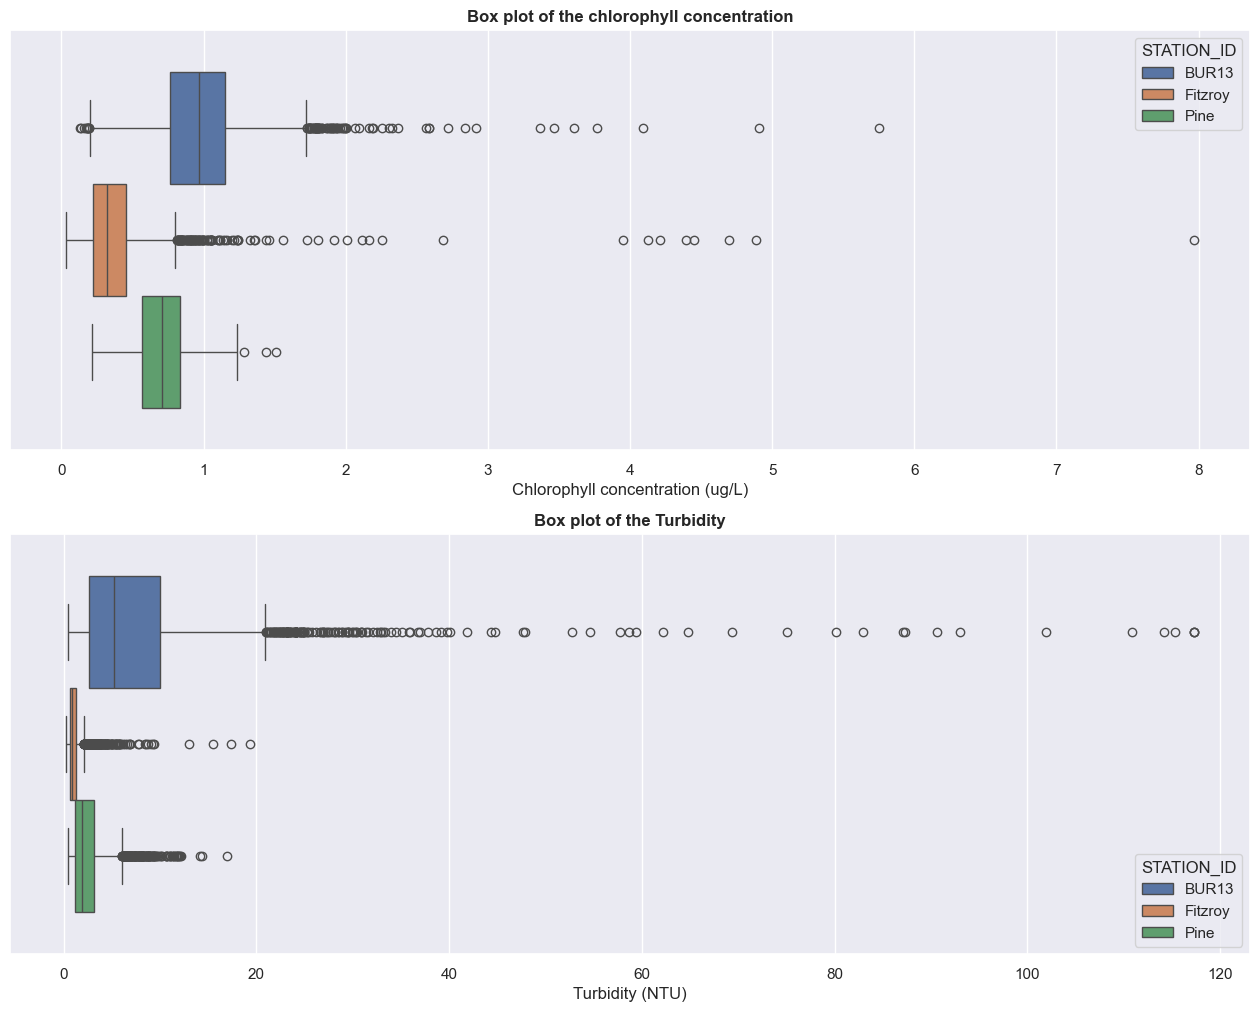

In [398]:
boxplot_fig = plt.figure(figsize=(16,12))

plt.subplot(2,1,1)

boxplot_ax = sns.boxplot(df,x="CHL_QA_AVG",hue="STATION_ID")
plt.xlabel("Chlorophyll concentration (ug/L)")
plt.title("Box plot of the chlorophyll concentration",fontweight="bold")

plt.subplot(2,1,2)

boxplot_ax = sns.boxplot(df,x="NTU_QA_AVG",hue="STATION_ID")
plt.xlabel("Turbidity (NTU)")
plt.title("Box plot of the Turbidity",fontweight="bold")

plt.show()

<span style="color:red"><strong>There are Outlier readings at all Stations, but the least are for the Chlorophyll readings at Pine. There are many Chlorophyll & Turbidity readings at Burkedin River Mouth mooring station that can be considered outliers. The above two box plots are great at demonstrating the distribution of the readings and gives further insight and comparison such as skewness, interquartile ranges, etc.</strong></span>